# 10 · Per-recording overview

EEG (Oz 1-40 Hz), breathing-belt envelope and GSR across the whole file, with stage shading.
A quick validity sanity view supporting the report's §3.

In [1]:
import warnings, pathlib, sys
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
_c = pathlib.Path.cwd()
REPO = next(p for p in [_c] + list(_c.parents) if (p / "analysis").is_dir())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
from analysis import dataset, eegkit as K
DATA_DIR = None
recs = dataset.discover(DATA_DIR)
_gi, LABEL = {}, {}
for _r in recs:
    _g = _r["group"]; _gi[_g] = _gi.get(_g, 0) + 1
    LABEL[_r["key"]] = ("exp" if _g == "E" else "ctrl") + str(_gi[_g])
def lbl(r): return LABEL[r["key"]]
FIG = REPO / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
def ec_window(r):
    st = K.get_stages(K.load(r["path"]), r["key"])
    return [s for s in st if s[0].startswith("rest_close")][0]
def get_iaf(r):
    raw = K.load(r["path"]); ec = ec_window(r)
    _, live = K.get(raw, ec[1], ec[2]); return K.iaf(raw, live, ec[1], ec[2])
def stage_of(r, nm):
    st = K.get_stages(K.load(r["path"]), r["key"]); return [s for s in st if s[0] == nm]
print(f"discovered {len(recs)} recordings ->", {lbl(r): r["group"] for r in recs})

STAGE_COLORS = {"rest_open":"lightblue","rest_close":"cyan","hypervent":"orange",
                "reading":"lightgreen","speech":"lightcoral"}
def _col(nm):
    for k,v in STAGE_COLORS.items():
        if nm.startswith(k): return v
    return "grey"

discovered 4 recordings -> {'exp1': 'E', 'exp2': 'E', 'ctrl1': 'C', 'ctrl2': 'C'}


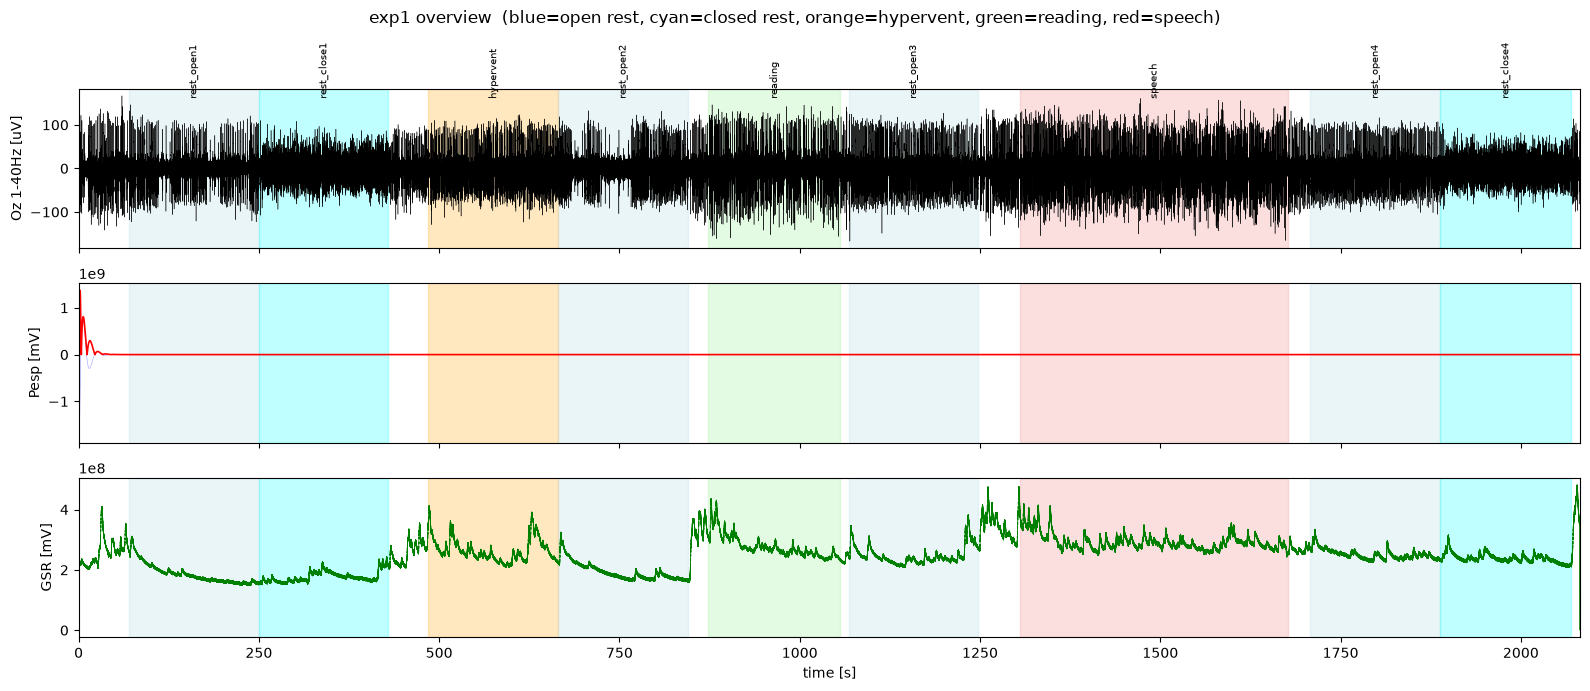

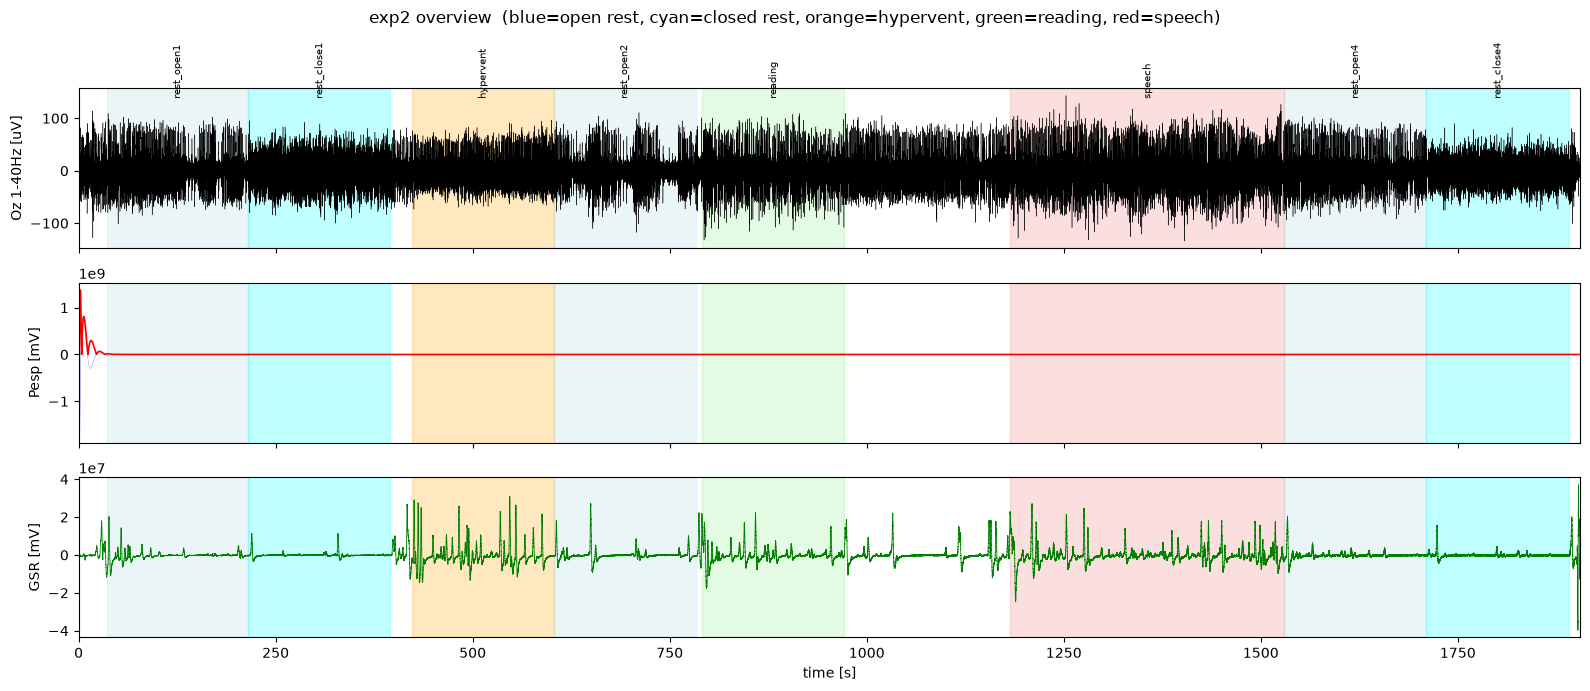

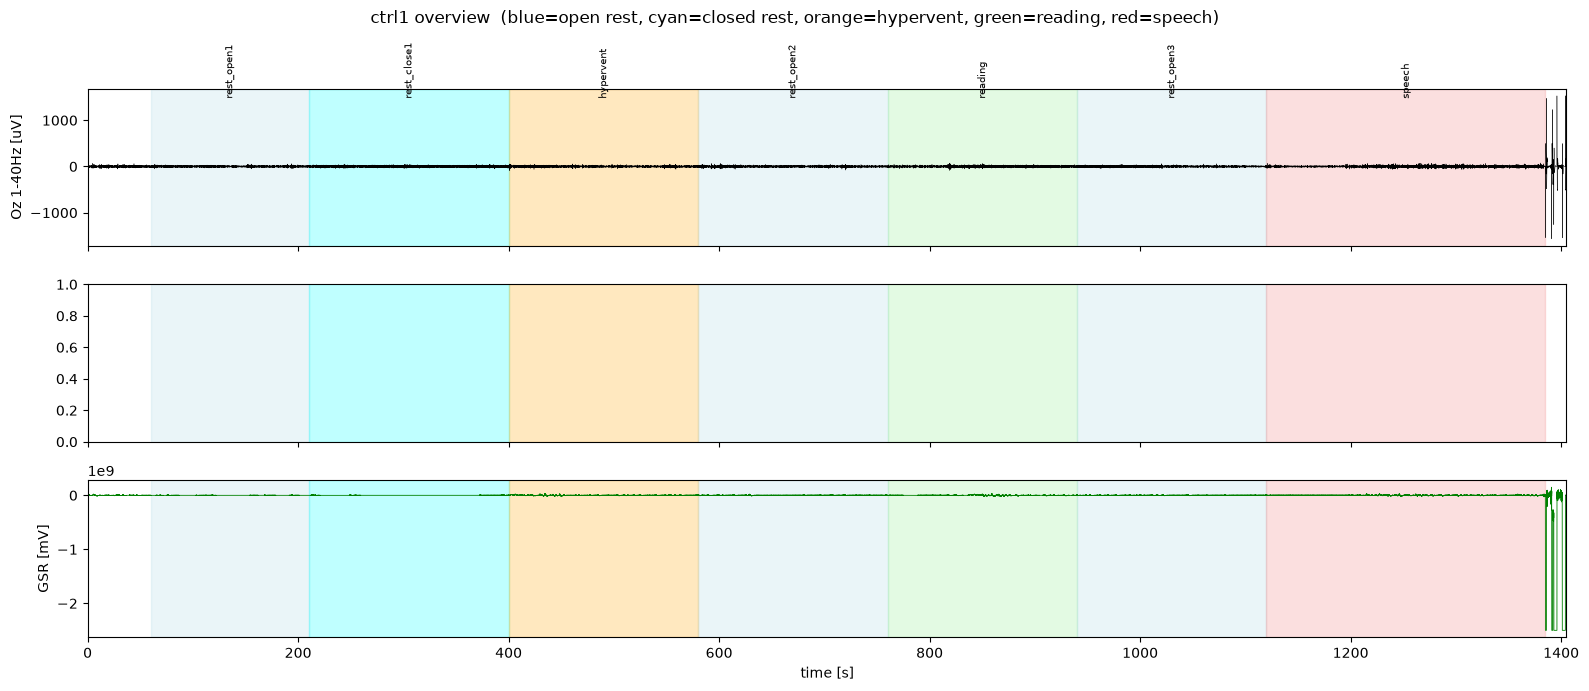

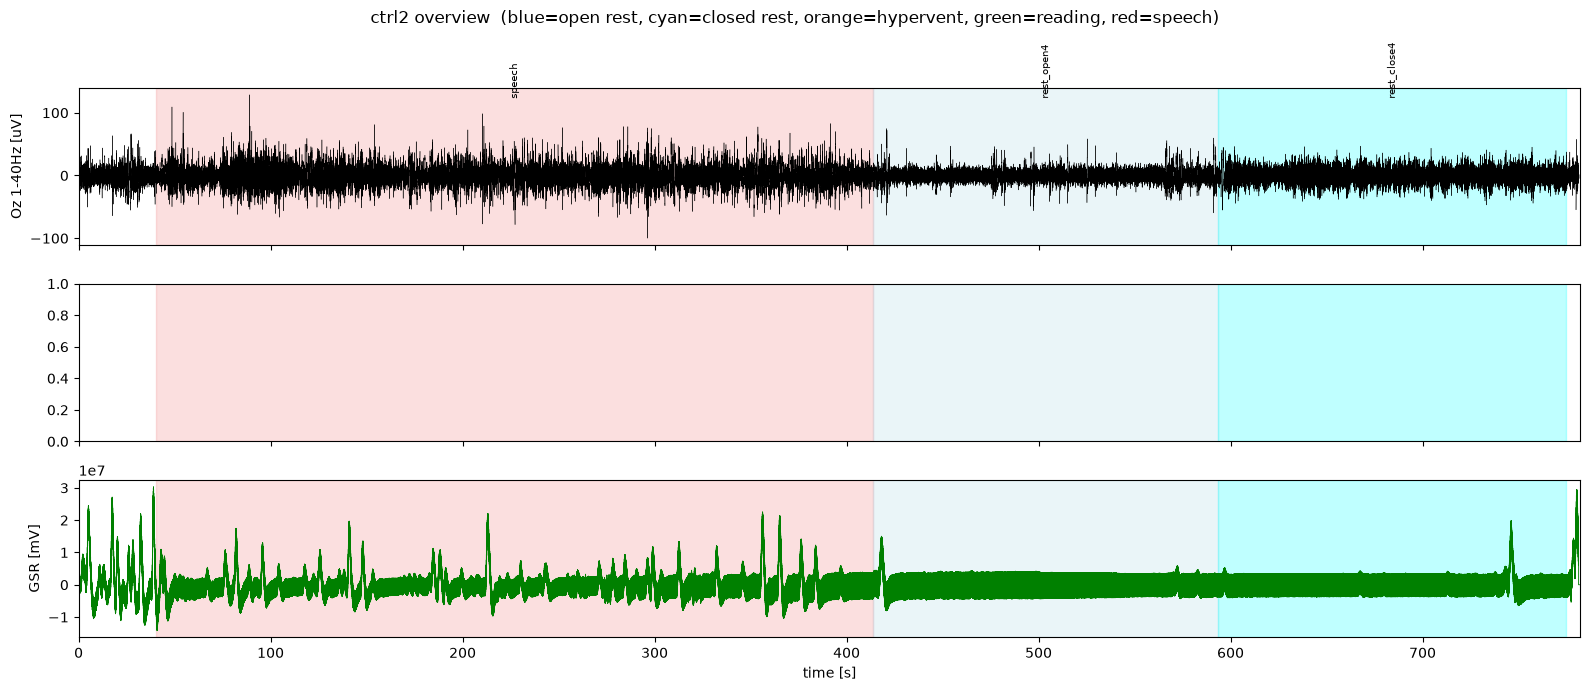

overview figures written to reports/figures (neutral names)


In [2]:
from scipy.signal import butter, sosfilt
def bp_(x,fs,lo,hi): return sosfilt(butter(3,[lo,hi],btype="band",fs=fs,output="sos"),x)
for r in recs:
    raw=K.load(r["path"]); fs=raw.info["sfreq"]; x=raw.get_data()*1e6
    st=K.get_stages(raw, r["key"]); t=np.arange(raw.n_times)/fs
    fig,axes=plt.subplots(3,1,figsize=(16,7),sharex=True)
    if "Oz" in raw.ch_names:
        axes[0].plot(t, bp_(x[raw.ch_names.index("Oz")],fs,1,40), lw=0.3, color="k"); axes[0].set_ylabel("Oz 1-40Hz [uV]")
    rc,_=K.resp_channel(raw,60,min(240,raw.n_times/fs))
    if rc:
        resp=bp_(x[raw.ch_names.index(rc)]*1e3,fs,0.05,0.5)
        env=np.abs(sosfilt(butter(2,0.3,btype="low",fs=fs,output="sos"),resp))
        axes[1].plot(t,resp,lw=0.3,color="b",alpha=0.5); axes[1].plot(t,env,lw=1.2,color="r"); axes[1].set_ylabel(f"{rc} [mV]")
    if "GSR" in raw.ch_names:
        axes[2].plot(t,x[raw.ch_names.index("GSR")]*1e3,lw=0.6,color="g"); axes[2].set_ylabel("GSR [mV]")
    axes[2].set_xlabel("time [s]")
    for ax in axes:
        for name,a,b in st: ax.axvspan(a,b,alpha=0.25,color=_col(name)); ax.set_xlim(0,t[-1])
    for name,a,b in st: axes[0].text((a+b)/2,axes[0].get_ylim()[1]*0.9,name,ha="center",fontsize=7,rotation=90)
    fig.suptitle(f"{lbl(r)} overview  (blue=open rest, cyan=closed rest, orange=hypervent, green=reading, red=speech)")
    fig.tight_layout(); fig.savefig(FIG/f"overview_{lbl(r)}.png",dpi=90); plt.show(); plt.close(fig)
print("overview figures written to reports/figures (neutral names)")
